## 1) Use Pandas’ read_csv function directly on this URL to open it as a DataFrame

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv"

df_raw = pd.read_csv(url)

print("First 5 rows:")
display(df_raw.head())

print("\nDataFrame info:")
df_raw.info()

First 5 rows:


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type
0,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,ak11155107,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake
1,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,nn00436847,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake
2,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,ak11151142,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake
3,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,ak11151135,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake
4,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,ci37171541,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120108 entries, 0 to 120107
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   time       120108 non-null  object 
 1   latitude   120108 non-null  float64
 2   longitude  120108 non-null  float64
 3   depth      120107 non-null  float64
 4   mag        120065 non-null  float64
 5   magType    120065 non-null  object 
 6   nst        59688 non-null   float64
 7   gap        94935 non-null   float64
 8   dmin       85682 non-null   float64
 9   rms        119716 non-null  float64
 10  net        120108 non-null  object 
 11  id         120108 non-null  object 
 12  updated    120108 non-null  object 
 13  place      120108 non-null  object 
 14  type       120108 non-null  object 
dtypes: float64(8), object(7)
memory usage: 13.7+ MB


## 2) Re-read the data in such a way that all date columns are identified as dates and the earthquake ID is used as the index

In [3]:
date_cols = [col for col in df_raw.columns if "date" in col.lower() or "time" in col.lower()]
print("Detected date columns:", date_cols)

df = pd.read_csv(url, parse_dates=date_cols, index_col="id")

print("First 5 rows after parsing dates and setting index:")
display(df.head())

print("\nDataFrame info after parsing:")
df.info()

Detected date columns: ['time', 'updated']
First 5 rows after parsing dates and setting index:


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type
id,,,,,,,,,,,,,,
ak11155107,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,2014-02-05 19:34:41.515000+00:00,"26km S of Redoubt Volcano, Alaska",earthquake
nn00436847,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,2014-02-01 01:35:09+00:00,"32km S of Alamo, Nevada",earthquake
ak11151142,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,2014-02-01 00:03:53.010000+00:00,"12km NNW of North Nenana, Alaska",earthquake
ak11151135,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,2014-01-31 23:41:25.007000+00:00,"22km S of Cantwell, Alaska",earthquake
ci37171541,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,2014-02-01 00:13:20.107000+00:00,"10km WNW of Progreso, Mexico",earthquake



DataFrame info after parsing:
<class 'pandas.core.frame.DataFrame'>
Index: 120108 entries, ak11155107 to ak11453389
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype              
---  ------     --------------   -----              
 0   time       120108 non-null  datetime64[ns]     
 1   latitude   120108 non-null  float64            
 2   longitude  120108 non-null  float64            
 3   depth      120107 non-null  float64            
 4   mag        120065 non-null  float64            
 5   magType    120065 non-null  object             
 6   nst        59688 non-null   float64            
 7   gap        94935 non-null   float64            
 8   dmin       85682 non-null   float64            
 9   rms        119716 non-null  float64            
 10  net        120108 non-null  object             
 11  updated    120108 non-null  datetime64[ns, UTC]
 12  place      120108 non-null  object             
 13  type       120108 non-null  object             
dt

## 3) Use describe to get the basic statistics of all the columns

In [4]:
print("Basic statistics:")
display(df.describe(include="all"))

print("Lowest magnitude:", df["mag"].min())
print("Highest magnitude:", df["mag"].max())

Basic statistics:


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type
count,120108,120108.000000,120108.000000,120107.000000,120065.000000,120065,59688.000000,94935.000000,85682.000000,119716.000000,120108,120108,120108,120108
unique,NaN,NaN,NaN,NaN,NaN,18,NaN,NaN,NaN,NaN,14,NaN,45395,11
top,NaN,NaN,NaN,NaN,NaN,ml,NaN,NaN,NaN,NaN,ak,NaN,"10km E of Mammoth Lakes, California",earthquake
freq,NaN,NaN,NaN,NaN,NaN,57608,NaN,NaN,NaN,NaN,31851,NaN,2201,118398
mean,2014-07-05 09:10:37.116720128,38.399579,-99.961402,28.375029,1.793958,NaN,17.878284,124.048978,0.893198,0.358174,NaN,2014-08-04 04:22:28.357678080+00:00,NaN,NaN
min,2014-01-01 00:01:16.610000,-73.462000,-179.998900,-9.900000,-0.970000,NaN,0.000000,9.000000,0.000000,0.000000,NaN,2014-01-01 00:38:24.983000+00:00,NaN,NaN
25%,2014-04-08 03:43:10.768999936,34.228917,-147.742025,4.100000,0.820000,NaN,8.000000,74.000000,0.020760,0.070000,NaN,2014-04-30 21:18:25+00:00,NaN,NaN
50%,2014-07-07 10:44:06.035000064,38.805300,-120.832000,9.200000,1.400000,NaN,14.000000,107.000000,0.073670,0.200000,NaN,2014-08-06 21:06:23.051500032+00:00,NaN,NaN
75%,2014-09-30 23:36:40.595000064,53.889500,-116.068100,22.880000,2.400000,NaN,22.000000,155.000000,0.447000,0.590000,NaN,2014-10-31 19:05:46.865999872+00:00,NaN,NaN
max,2014-12-31 23:54:33.900000,86.651400,179.998000,697.360000,8.200000,NaN,365.000000,356.400000,64.498000,8.460000,NaN,2015-08-21 00:06:53.450000+00:00,NaN,NaN


Lowest magnitude: -0.97
Highest magnitude: 8.2


## 4) Use nlargest to get the top 20 earthquakes by magnitude

In [5]:
top20 = df.nlargest(20, "mag")
display(top20[["time", "place", "mag", "depth", "latitude", "longitude"]])

,time,place,mag,depth,latitude,longitude
id,,,,,,
usc000nzvd,2014-04-01 23:46:47.260,"94km NW of Iquique, Chile",8.2,25.00,-19.6097,-70.7691
usc000rki5,2014-06-23 20:53:09.700,"19km SE of Little Sitkin Island, Alaska",7.9,109.00,51.8486,178.7352
usc000p27i,2014-04-03 02:43:13.110,"53km SW of Iquique, Chile",7.7,22.40,-20.5709,-70.4931
usc000phx5,2014-04-12 20:14:39.300,"93km SSE of Kirakira, Solomon Islands",7.6,22.56,-11.2701,162.1481
usb000pr89,2014-04-19 13:28:00.810,"70km SW of Panguna, Papua New Guinea",7.5,43.37,-6.7547,155.0241
usc000piqj,2014-04-13 12:36:19.230,"112km S of Kirakira, Solomon Islands",7.4,39.00,-11.4633,162.0511
usb000slwn,2014-10-14 03:51:34.460,"74km S of Intipuca, El Salvador",7.3,40.00,12.5262,-88.1225
usb000pq41,2014-04-18 14:27:24.920,"33km ESE of Petatlan, Mexico",7.2,24.00,17.3970,-100.9723
usc000pft9,2014-04-11 07:07:23.130,"56km WSW of Panguna, Papua New Guinea",7.1,60.53,-6.5858,155.0485


## 5) Extract the state or country using Pandas text data functions

In [6]:
df["country"] = df["place"].str.split(",").str[-1].str.strip()

display(df[["place", "country"]].head(10))

,place,country
id,,
ak11155107,"26km S of Redoubt Volcano, Alaska",Alaska
nn00436847,"32km S of Alamo, Nevada",Nevada
ak11151142,"12km NNW of North Nenana, Alaska",Alaska
ak11151135,"22km S of Cantwell, Alaska",Alaska
ci37171541,"10km WNW of Progreso, Mexico",Mexico
ci11419722,"3km N of Tijuana, Mexico",Mexico
ci11419714,"11km N of Borrego Springs, California",California
ak11151127,"61km NNW of Talkeetna, Alaska",Alaska
ak11151125,"48km NNE of Kodiak, Alaska",Alaska


## 6) Display each unique value from the new column

In [7]:
unique_countries = df["country"].unique()
print("Unique country/state values:")
print(unique_countries)

print("\nNumber of unique values:", len(unique_countries))

Unique country/state values:
['Alaska' 'Nevada' 'Mexico' 'California' 'Papua New Guinea' 'New Zealand'
 'Missouri' 'South of the Fiji Islands' 'Montana' 'British Virgin Islands'
 'Washington' 'Oregon' 'Canada' 'Fiji' 'Wyoming' 'Antarctica' 'Chile'
 'Utah' 'Indonesia' 'Solomon Islands' 'Micronesia' 'Oklahoma' 'Hawaii'
 'Russia' 'Arizona' 'Philippines' 'Bolivia' 'Greece' 'Japan' 'Puerto Rico'
 'Iran' 'Tonga' 'Wallis and Futuna' 'Colorado' 'Guam' 'CA'
 'Carlsberg Ridge' 'Idaho' 'Pakistan'
 'Off the west coast of northern Sumatra' 'Burma' 'China' 'Peru'
 'Off the east coast of the North Island of New Zealand' 'Costa Rica'
 'Reykjanes Ridge' 'East Timor' 'Central East Pacific Rise'
 'Mid-Indian Ridge' 'Japan region' 'Northern Mariana Islands'
 'El Salvador' 'Samoa' 'Northern Mid-Atlantic Ridge' 'Taiwan' 'Arkansas'
 'South Sandwich Islands' 'Colombia' 'Dominican Republic' 'Argentina'
 'Texas' 'New Hampshire' 'Saint Helena' 'West of Vancouver Island'
 'Tanzania' 'Vanuatu' 'Bosnia and Herzegov

## 7) Create a filtered dataset that only has earthquakes of magnitude 4 or larger and (assuming just >= magnitude 4)

In [8]:
df_filtered = df[df["mag"] >= 4].copy()

print("Filtered dataset shape:", df_filtered.shape)
display(df_filtered.head())

Filtered dataset shape: (17547, 15)


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type,country
id,,,,,,,,,,,,,,,
usc000mqlp,2014-01-31 23:08:03.660,-4.9758,153.9466,110.18,4.2,mb,NaN,98.0,1.940,0.61,us,2014-04-08 01:43:19+00:00,"115km ESE of Taron, Papua New Guinea",earthquake,Papua New Guinea
usc000mqln,2014-01-31 22:54:32.970,-28.1775,-177.9058,95.84,4.3,mb,NaN,104.0,1.063,1.14,us,2014-04-08 01:43:19+00:00,"120km N of Raoul Island, New Zealand",earthquake,New Zealand
usc000mqls,2014-01-31 22:49:49.740,-23.1192,179.1174,528.34,4.4,mb,NaN,80.0,5.439,0.95,us,2014-04-08 01:43:19+00:00,South of the Fiji Islands,earthquake,South of the Fiji Islands
usc000mf1x,2014-01-31 22:19:44.330,51.1569,-178.0910,37.50,4.2,mb,NaN,NaN,NaN,0.83,us,2014-04-08 01:43:19+00:00,"72km E of Amatignak Island, Alaska",earthquake,Alaska
usc000mqlm,2014-01-31 21:56:44.320,-4.8800,153.8434,112.66,4.3,mb,NaN,199.0,1.808,0.79,us,2014-04-08 01:43:19+00:00,"100km ESE of Taron, Papua New Guinea",earthquake,Papua New Guinea


## 8) Using the filtered dataset (magnitude > 4), count the number of earthquakes in each country/state. Make a bar chart of this number for the top 5 locations with the most earthquakes

Top 5 locations with most M>=4 earthquakes:


country
Indonesia           2116
Papua New Guinea    1354
Japan               1150
Chile               1124
New Zealand          758
Name: count, dtype: int64

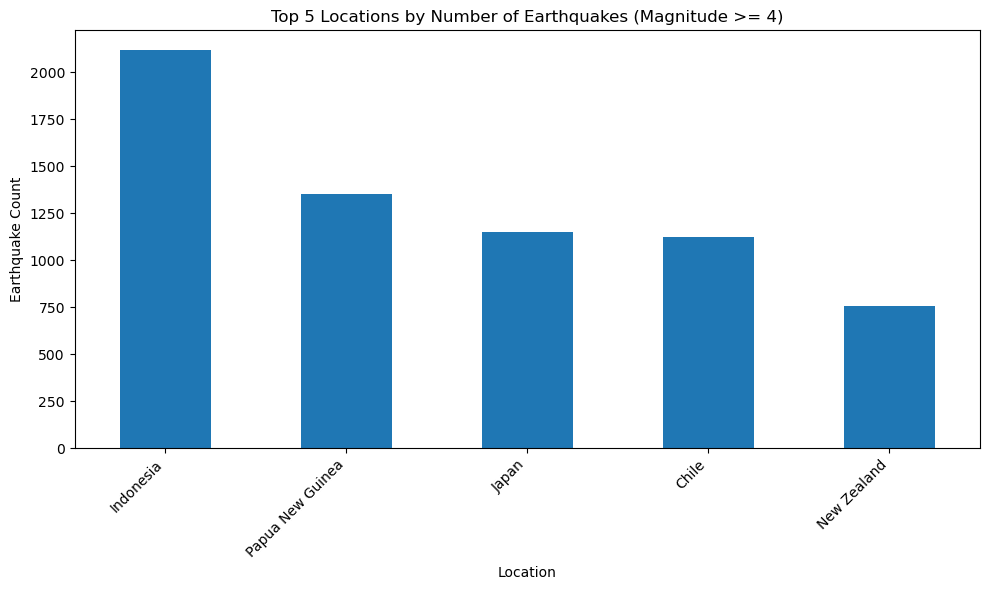

In [9]:
country_counts = df_filtered["country"].value_counts()
top5 = country_counts.head(5)

print("Top 5 locations with most M>=4 earthquakes:")
display(top5)

plt.figure(figsize=(10, 6))
top5.plot(kind="bar")
plt.title("Top 5 Locations by Number of Earthquakes (Magnitude >= 4)")
plt.xlabel("Location")
plt.ylabel("Earthquake Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9) Make a histogram the distribution of the Earthquake magnitudes

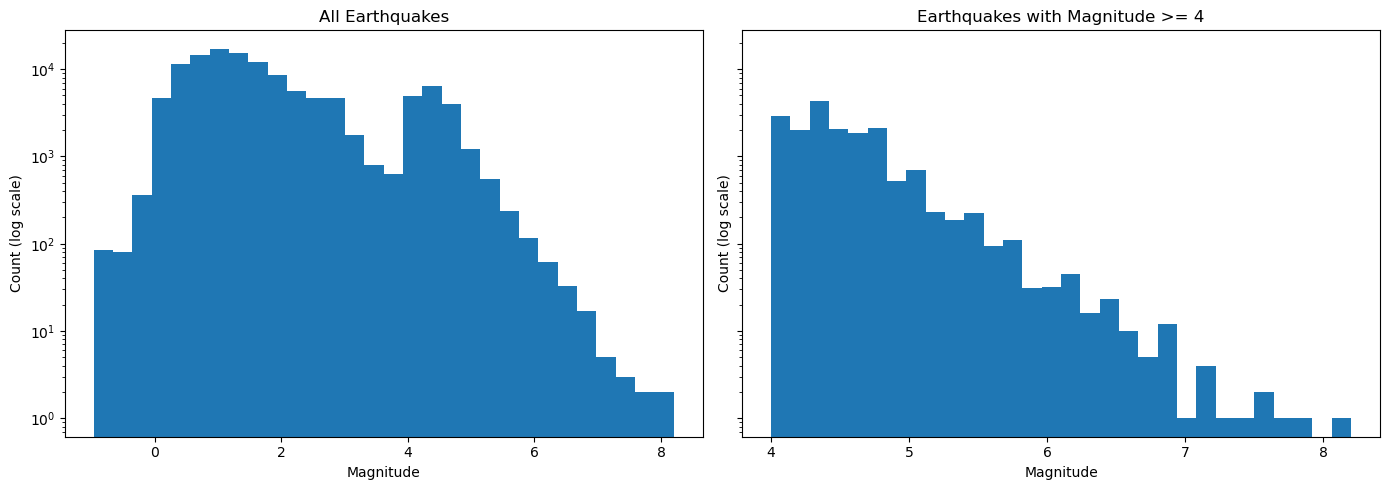

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Unfiltered
axes[0].hist(df["mag"].dropna(), bins=30, log=True)
axes[0].set_title("All Earthquakes")
axes[0].set_xlabel("Magnitude")
axes[0].set_ylabel("Count (log scale)")

# Filtered - magnitude >=4
axes[1].hist(df_filtered["mag"].dropna(), bins=30, log=True)
axes[1].set_title("Earthquakes with Magnitude >= 4")
axes[1].set_xlabel("Magnitude")
axes[1].set_ylabel("Count (log scale)")

plt.tight_layout()
plt.show()

### What relationship do you see?
There are many more small earthquakes than large ones. As magnitude increases, the number of earthquakes drops off quickly.

## 10) Visualize the locations of earthquakes by making a scatterplot of their latitude and longitude

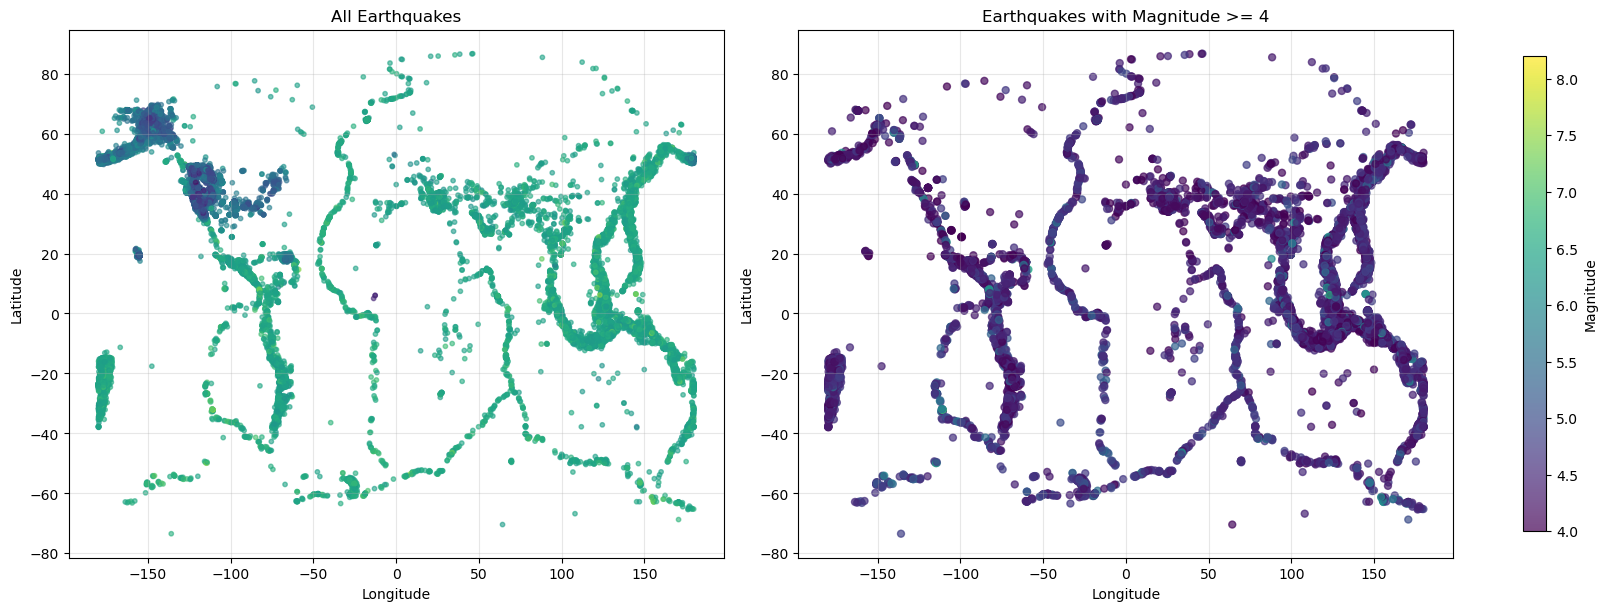

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# Unfiltered scatter
sc1 = axes[0].scatter(
    df["longitude"],
    df["latitude"],
    c=df["mag"],
    s=10,
    alpha=0.6
)
axes[0].set_title("All Earthquakes")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].grid(True, alpha=0.3)

# Filtered scatter
sc2 = axes[1].scatter(
    df_filtered["longitude"],
    df_filtered["latitude"],
    c=df_filtered["mag"],
    s=25,
    alpha=0.7
)
axes[1].set_title("Earthquakes with Magnitude >= 4")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].grid(True, alpha=0.3)

# One colorbar for the whole figure
cbar = fig.colorbar(sc2, ax=axes.ravel().tolist(), shrink=0.9)
cbar.set_label("Magnitude")

plt.show()

### What difference do you note?
The unfiltered dataset is much denser and more cluttered because it includes many small earthquakes. The filtered dataset makes the strongest earthquake zones easier to see.